# 모듈 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# KNN 알고리즘 분류기(classifier) 클래스
from sklearn.neighbors import KNeighborsClassifier

# 데이터 준비

In [2]:
file_path = "https://bit.ly/fish_csv_data"

In [3]:
fish = pd.read_csv(file_path)

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


# 데이터 탐색

## 카테고리 변수 탐색

In [6]:
fish.Species.value_counts()  # 물고기 종류 빈도수

,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


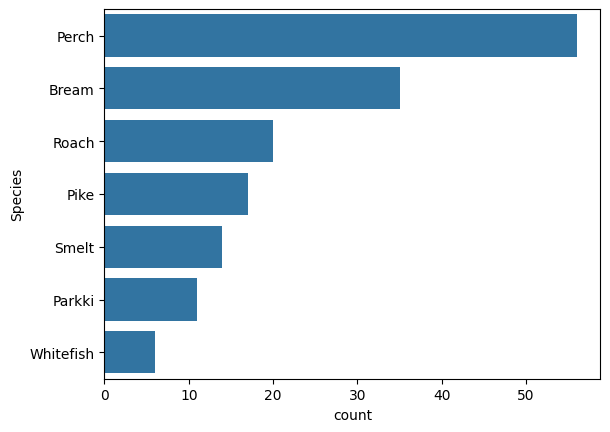

In [7]:
sns.countplot(data=fish, y="Species", order=fish.Species.value_counts().index)
plt.show()

## 연속형 자료들 탐색

In [8]:
fish.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


연속형 변수들의 histogram과 boxplot을 시각화.

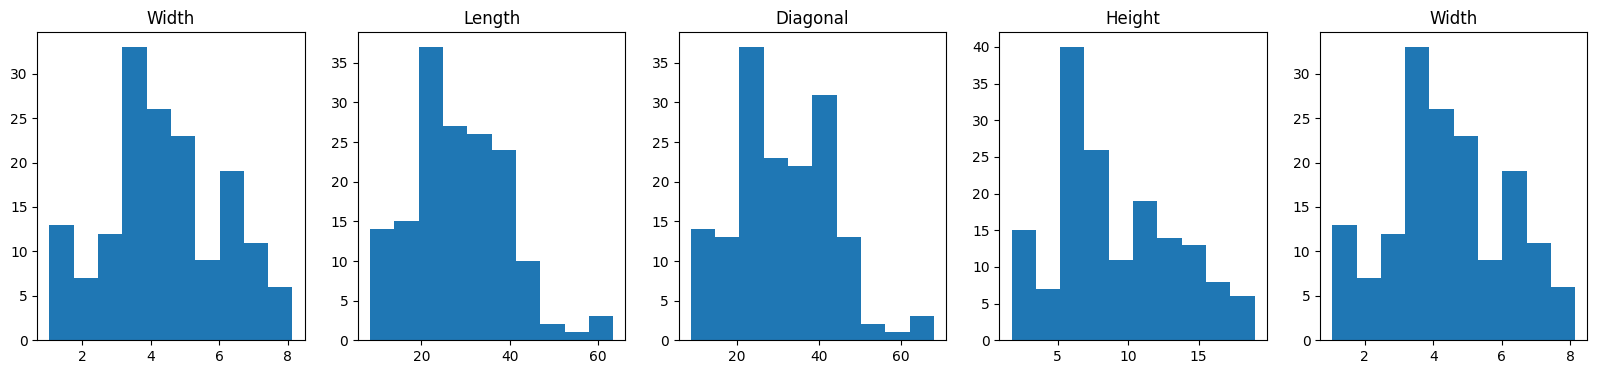

In [9]:
fishes = ["Width", "Length", "Diagonal", "Height", "Width"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, j in enumerate(fishes):
    axes[i].hist(fish[j])
    axes[i].set_title(j)


plt.show()

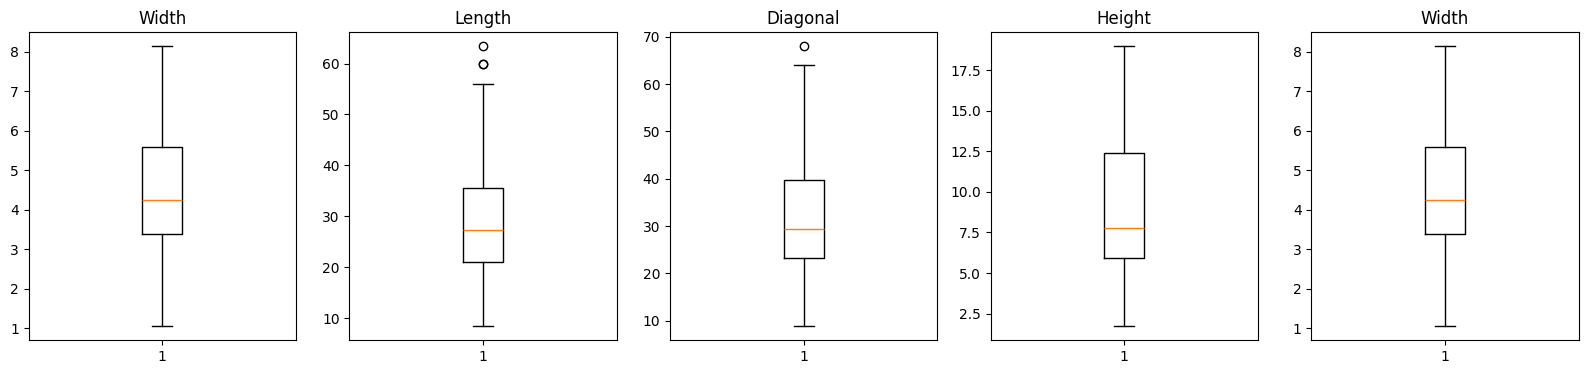

In [10]:
fishes = ["Width", "Length", "Diagonal", "Height", "Width"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, j in enumerate(fishes):
    axes[i].boxplot(fish[j])
    axes[i].set_title(j)


plt.show()

In [11]:
# 강사님 답안
features = fish.columns[1:]
print(features)

Index(['Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')


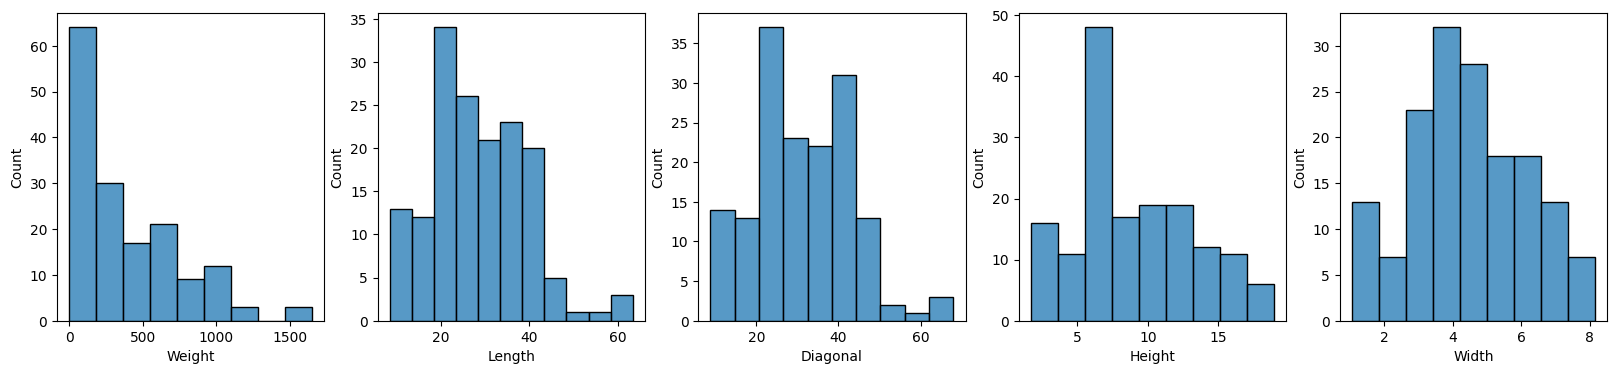

In [12]:
fig, axes = plt.subplots(ncols=5, figsize=(20, 4))

for i, var in enumerate(features):
    sns.histplot(data=fish, x=var, ax=axes[i])

plt.show()

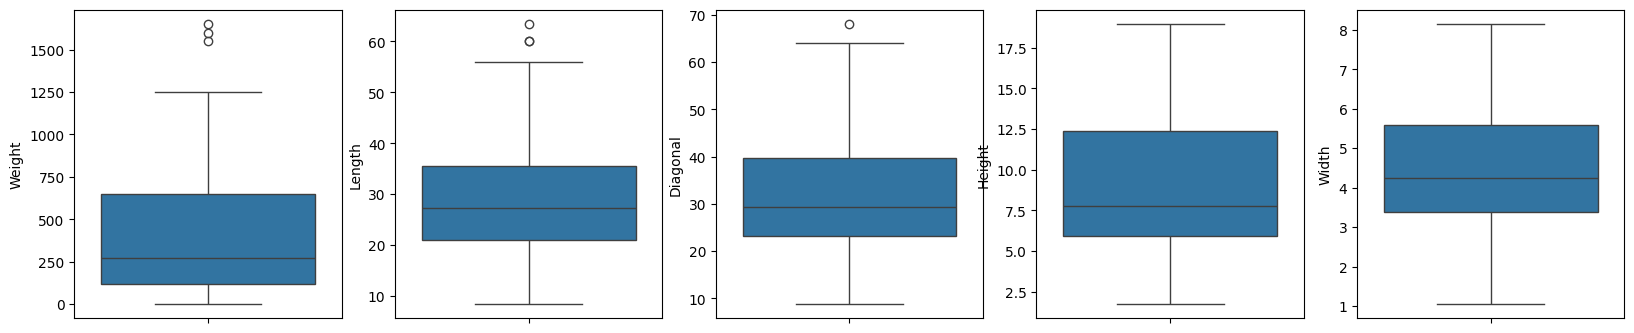

In [13]:
fig, axes = plt.subplots(ncols=5, figsize=(20, 4))

for i, var in enumerate(features):
    sns.boxplot(data=fish, y=var, ax=axes[i])

plt.show()

## 변수들 간의 상관관계 시각화

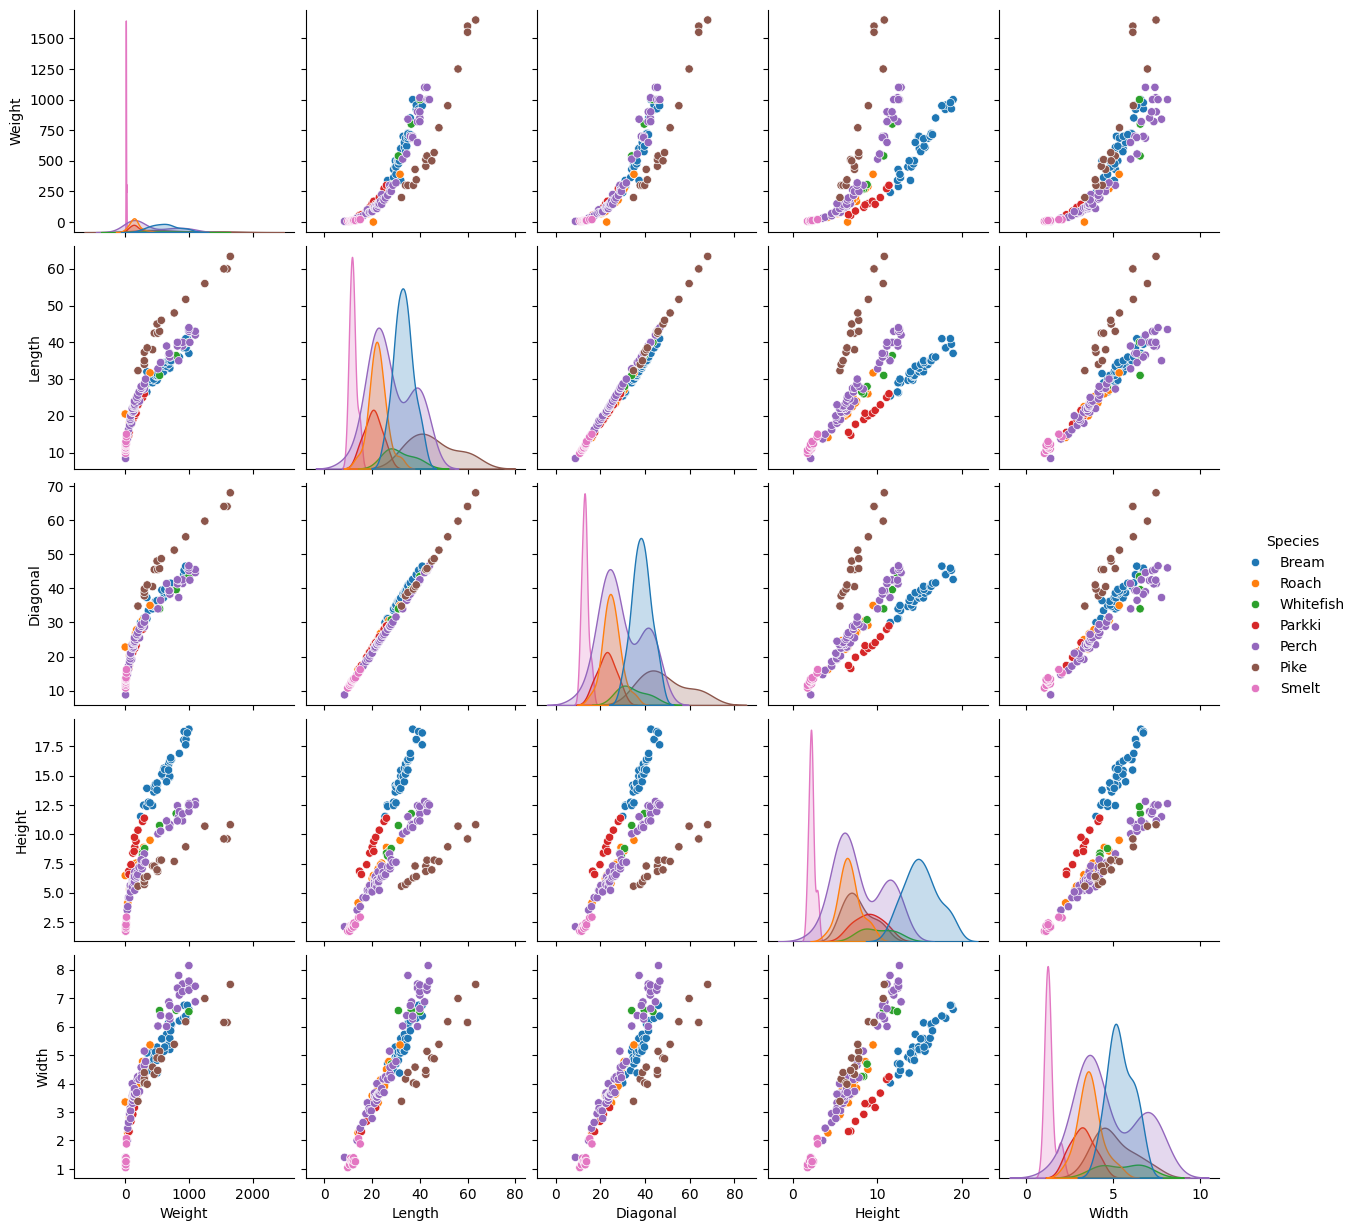

In [14]:
sns.pairplot(data=fish, hue="Species")
plt.show()

# 문제 정의

물고기의 무게와 길이를 알면 물고기의 종류(도미/빙어)를 예측할 수 있을까?
*   2개 변수를 사용한 이진분류(binary classification) 문제
    *   feature(특성, 변수) - Weight(무게), Length(길이)
    *   target, label(class) - Bream(도미), Smelt(빙어)

In [15]:
df = fish.loc[fish.Species.isin(["Bream", "Smelt"]), ["Species", "Weight", "Length"]]

In [16]:
# Jupyter 노트북에서 데이터프레임을 출력할 때 최대 행의 개수를 10개로 제한.
pd.set_option("display.max_rows", 10)

In [17]:
df

,Species,Weight,Length
0,Bream,242.0,25.4
1,Bream,290.0,26.3
2,Bream,340.0,26.5
3,Bream,363.0,29.0
4,Bream,430.0,29.0
...,...,...,...
154,Smelt,12.2,12.2
155,Smelt,13.4,12.4
156,Smelt,12.2,13.0
157,Smelt,19.7,14.3


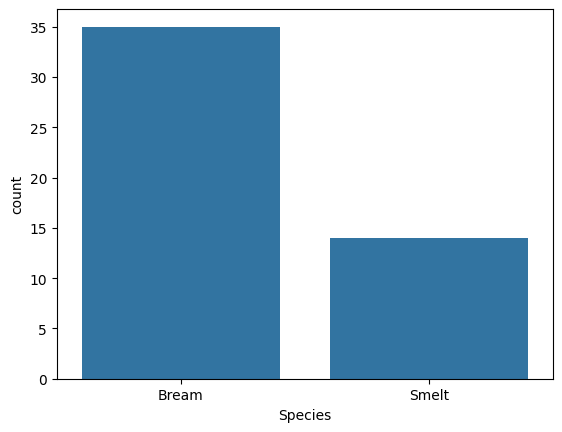

In [18]:
sns.countplot(data=df, x="Species")

plt.show()

In [42]:
df.Species.value_counts()

,count
Species,
Bream,35
Smelt,14


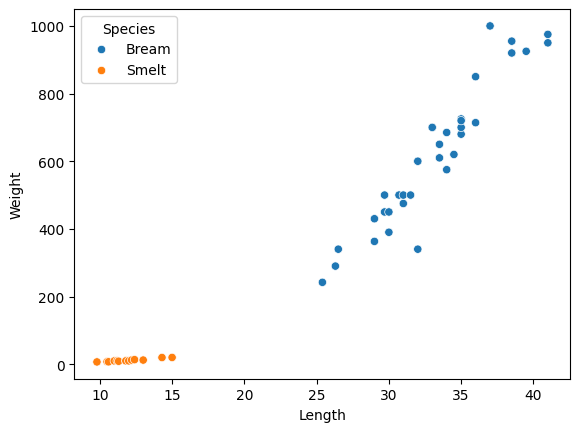

In [19]:
sns.scatterplot(data=df, x="Length", y="Weight", hue="Species")
plt.show()

scikit-learn 패키지의 머신러닝 알고리즘들은 데이터(feature)와 타겟(label) 배열을 구분해서 사용함.

특성 배열은 2차원 배열, 타겟 배열은 1차원 배열.

In [20]:
# 특성(feature) 배열
x = df[["Weight", "Length"]].values
x[:5, :]

array([[242. ,  25.4],
       [290. ,  26.3],
       [340. ,  26.5],
       [363. ,  29. ],
       [430. ,  29. ]])

In [21]:
# 타겟(target) 배열 - 1d array
y = df.Species.values
y

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

KNN 모델 훈련(학습)

KNN(K-Nearest Neighbors, K-최근접 이웃) 알고리즘:

*   k개의 가장 가까운 이웃들의 레이블을 사용해서 예측(분류)하는 머신러닝 알고리즘.
*   KNN 분류 알고리즘은 훈련(train) 시간이 필요하지 않음.
*   KNN 분류 알고리즘은 예측 시간이 오래 걸릴 수 있음.
    *   훈련 데이터와 테스트 데이터 사이의 거리들을 계산한 후에 가장 가까운 k개의 거리를 찾기 때문에.

In [22]:
# KNN 분류 알고리즘을 구현한 객체를 생성
knn_clf = KNeighborsClassifier()

In [23]:
# KNN 모델을 훈련 - 컴퓨터에게 레이블이 있는 특성들을 제공.
knn_clf.fit(x, y)

KNeighborsClassifier()

In [24]:
# 훈련된 KNN 모델로 예측.
predictions = knn_clf.predict(x)
print(predictions)

['Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt'
 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt'
 'Smelt' 'Smelt' 'Smelt' 'Smelt']


In [25]:
# 실젯값과 예측값을 비교
y == predictions

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [26]:
knn_clf.score(x, y)  # 정확도(accuracy)

1.0

# 가상의 물고기 데이터의 예측값

(600g, 30cm), (50g, 14cm) 물고기 데이터

In [27]:
x_test = np.array([[600, 30], [50, 14]])
x_test

array([[600,  30],
       [ 50,  14]])

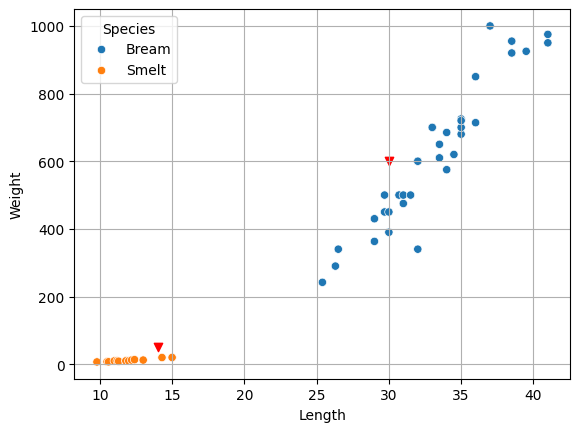

In [28]:
# 훈련 셋과 테스트 셋을 함께 시각화
sns.scatterplot(data=df, x="Length", y="Weight", hue="Species")  # 훈련 셋(35 도미, 14 빙어)

plt.scatter(x=x_test[:, 1], y=x_test[:, 0], color="Red", marker="v")

plt.grid()
plt.show()

In [29]:
# 가상의 물고기들(테스트 셋)의 예측값
test_predict = knn_clf.predict(X=x_test)
print(test_predict)

['Bream' 'Smelt']


In [30]:
# KNN 모델이 찾은 k개의 가장 가까운 이웃들(k-nearest neighbors)
distances, indices = knn_clf.kneighbors(X=x_test)
#> 리턴값 distances: k개의 가장 가까운 이웃까지의 거리들
#> 리턴값 indices: k개의 가장 가까운 이웃의 인덱스들.

In [31]:
print(indices)

[[15 14 18 22 20]
 [48 47 45 46 44]]


In [32]:
# 첫번째 테스트 물고기(600g, 30cm)에서 가장 가까운 5개의 훈련 셋 안의 물고기들.
x[indices[0]]

array([[600. ,  32. ],
       [600. ,  32. ],
       [610. ,  33.5],
       [620. ,  34.5],
       [575. ,  34. ]])

In [33]:
print(distances)

[[ 2.          2.         10.59481005 20.5        25.3179778 ]
 [30.11660671 30.30148511 36.63495598 37.8132252  37.84283287]]


In [34]:
y[indices[0]]  # 첫번째 테스트 물고기 예측값을 알아내기 위해 사용한 레이블들

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

In [35]:
# 두번째 테스트 물고기(50g, 14cm)에서 가장 가까운 5개의 훈련 셋 안의 물고기들
x[indices[1]]

array([[19.9, 15. ],
       [19.7, 14.3],
       [13.4, 12.4],
       [12.2, 13. ],
       [12.2, 12.2]])

In [36]:
y[indices[1]]

array(['Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'], dtype=object)

# K 값에 따른 정확도 변화

In [37]:
k_values = np.arange(1, 50)  # 가장 가까운 이웃들의 개수로 사용할 배열
accuracies = []  # k 값에 따른 정확도들을 저장할 리스트.

for k in k_values:
    # KNN 분류기 객체 생성
    knn = KNeighborsClassifier(n_neighbors=k)
    # KNN 분류기 모델 훈련
    knn.fit(x, y)
    # 훈련 셋 예측값의 정확도
    acc = knn.score(x, y)
    accuracies.append(acc)

print(accuracies)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9795918367346939, 1.0, 0.9795918367346939, 0.9795918367346939, 0.9795918367346939, 0.9795918367346939, 0.9795918367346939, 0.9795918367346939, 0.9795918367346939, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143]


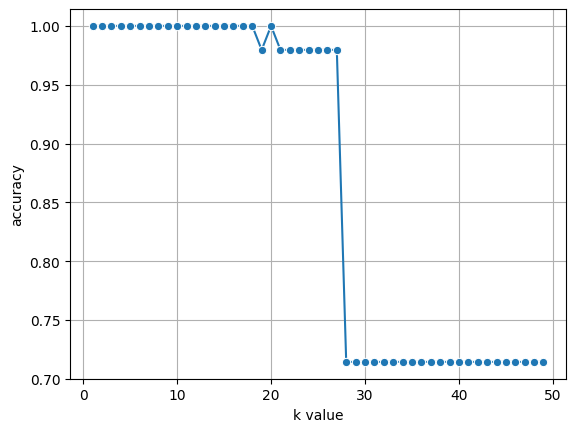

In [40]:
sns.lineplot(x=k_values, y=accuracies, marker="o")

plt.xlabel("k value")
plt.ylabel("accuracy")
plt.grid()
plt.show()

In [43]:
35/49

0.7142857142857143